## Step 1: Loading and Splitting Data

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
file_path = 'Group03/Regression/UnivariateData/3.csv'
data = pd.read_csv(file_path)

# Assuming the dataset has one column of input data and one column of output data
X = data.iloc[:, 0].values  # Input (independent variable)
y = data.iloc[:, 1].values  # Output (dependent variable)

# Split the dataset into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Step 2: Polynomial Curve Fitting with Cross-Validation

Weights for degree-2 polynomial: [ 0.         -1.81821571 -0.08152088]
MSE (Train): 0.20156078603151703, MSE (Test): 0.19083173956874017


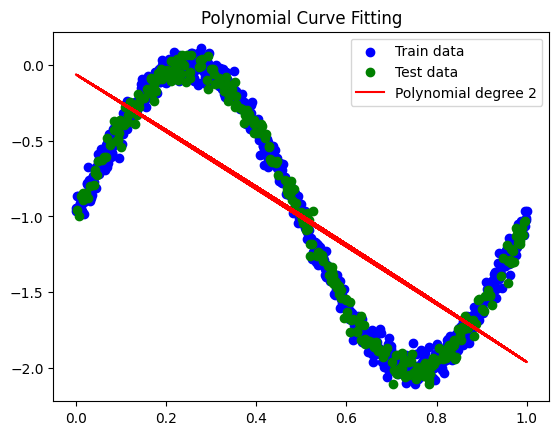

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to perform polynomial fitting
def polynomial_regression(X_train, y_train, X_test, y_test, degree, alpha=0):
    # Generate polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train.reshape(-1, 1))
    X_test_poly = poly_features.fit_transform(X_test.reshape(-1, 1))
    
    # Perform polynomial regression with Ridge regularization
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    
    # Predict the values
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Calculate the mean squared error
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    return y_train_pred, y_test_pred, model.coef_, mse_train, mse_test

# Example: Fit a degree-2 polynomial without regularization
degree = 2
y_train_pred, y_test_pred, weights, mse_train, mse_test = polynomial_regression(X_train, y_train, X_test, y_test, degree)
print(f"Weights for degree-{degree} polynomial: {weights}")
print(f"MSE (Train): {mse_train}, MSE (Test): {mse_test}")

# Plot the polynomial curve
plt.scatter(X_train, y_train, color='blue', label='Train data')
plt.scatter(X_test, y_test, color='green', label='Test data')
plt.plot(X_train, y_train_pred, color='red', label=f'Polynomial degree {degree}')
plt.title('Polynomial Curve Fitting')
plt.legend()
plt.show()

## Step 3: Model Complexity and Regularization

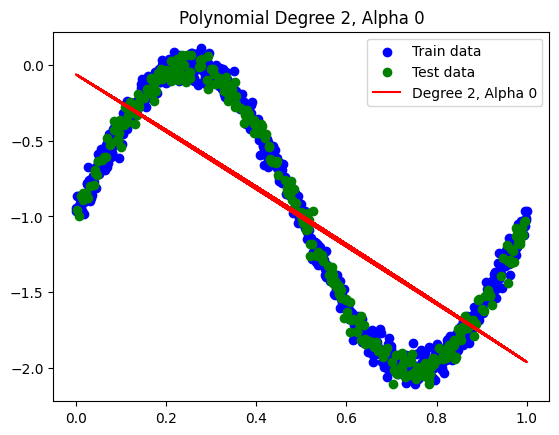

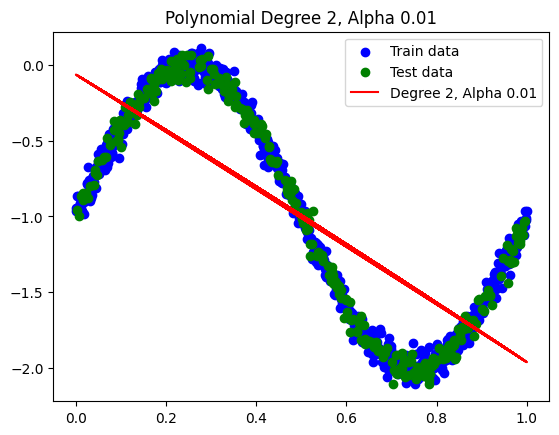

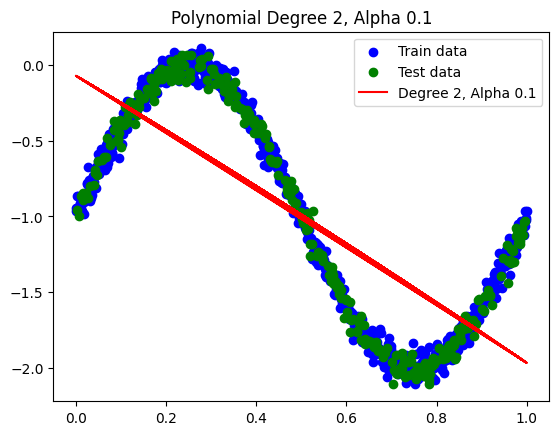

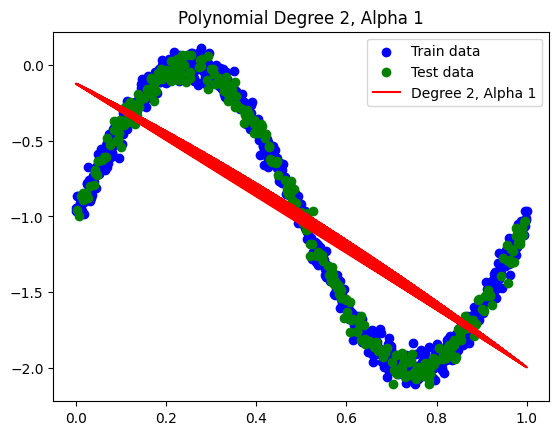

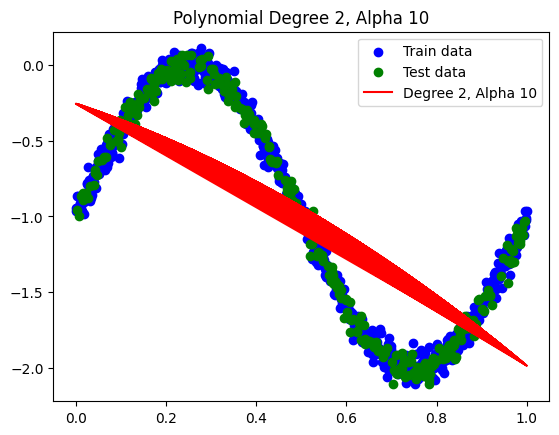

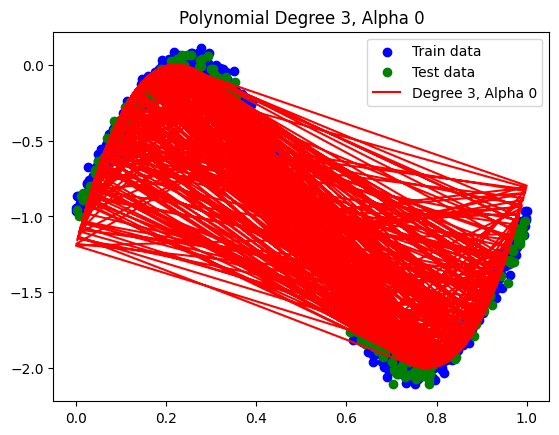

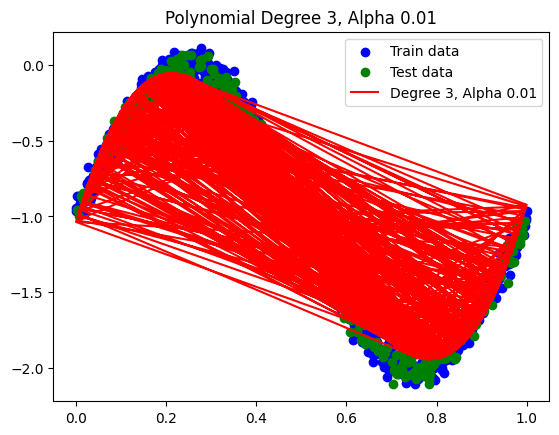

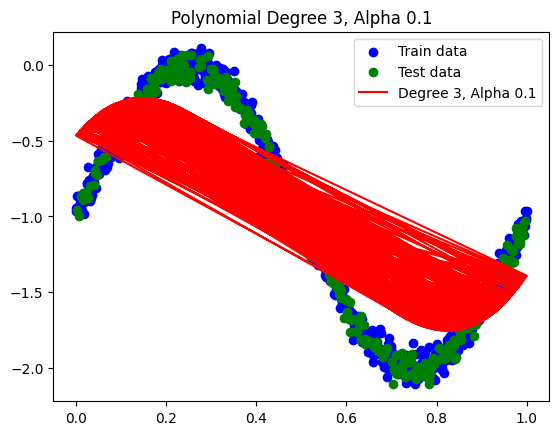

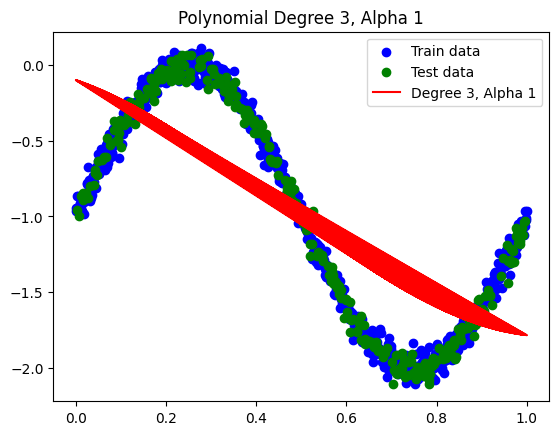

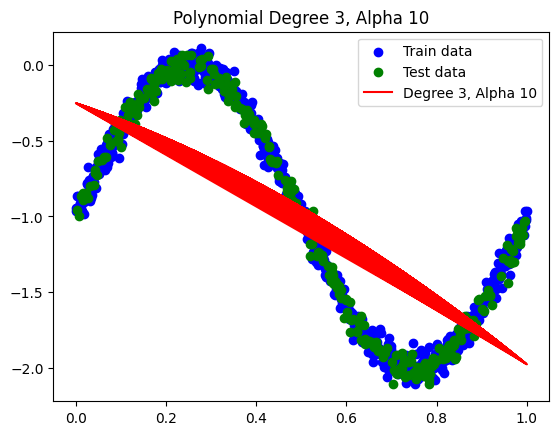

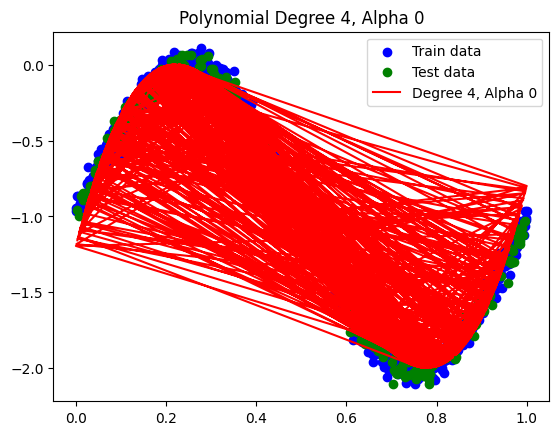

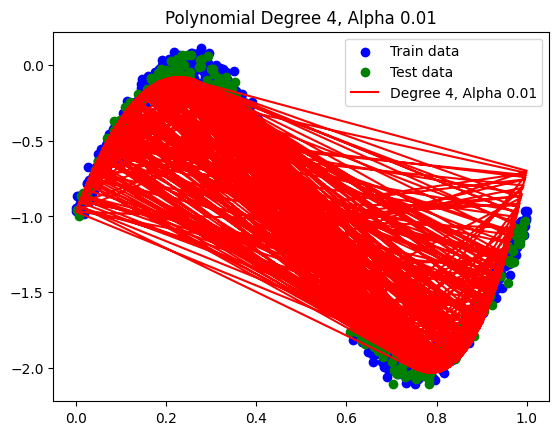

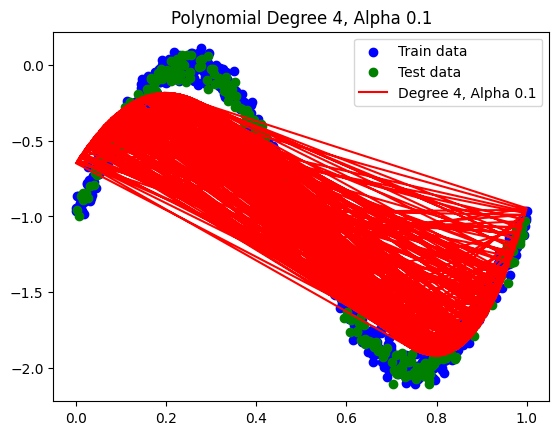

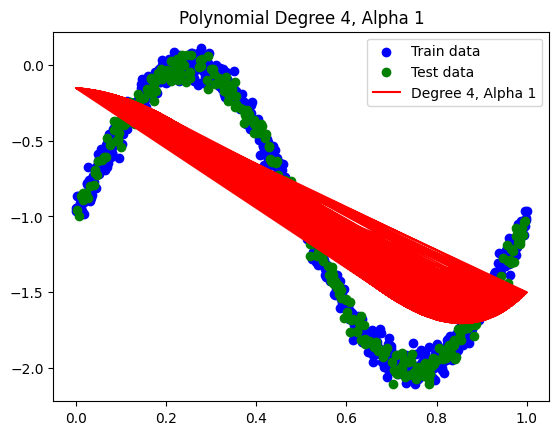

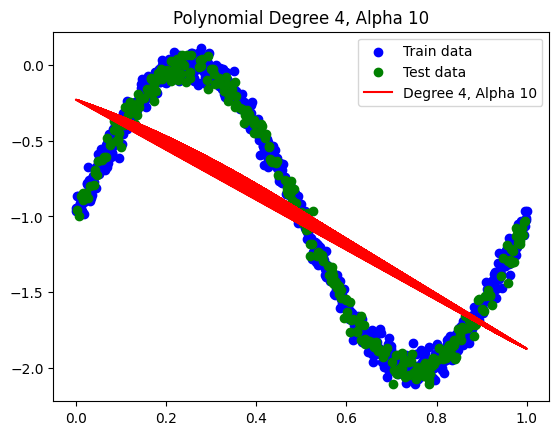

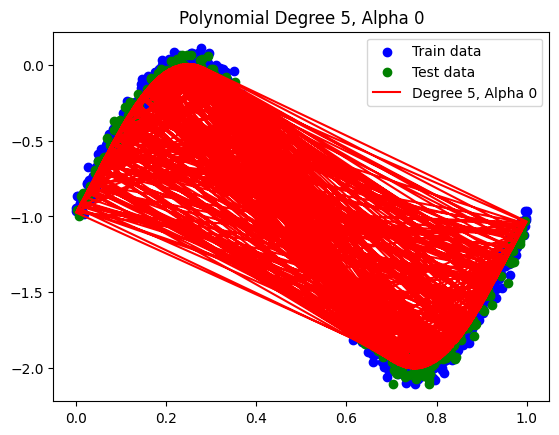

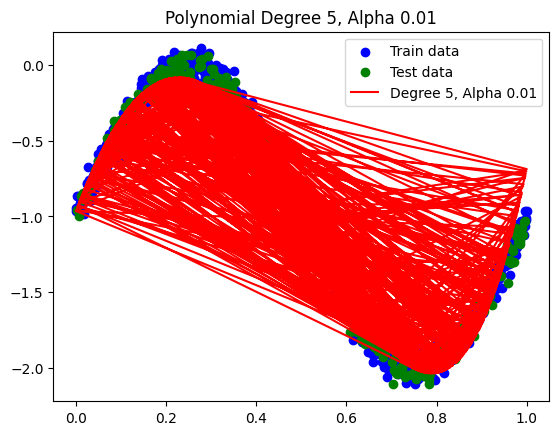

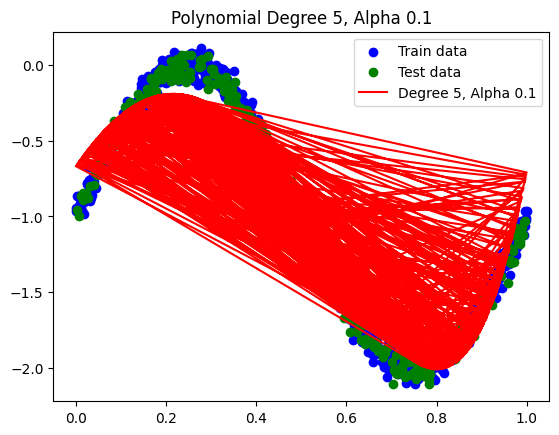

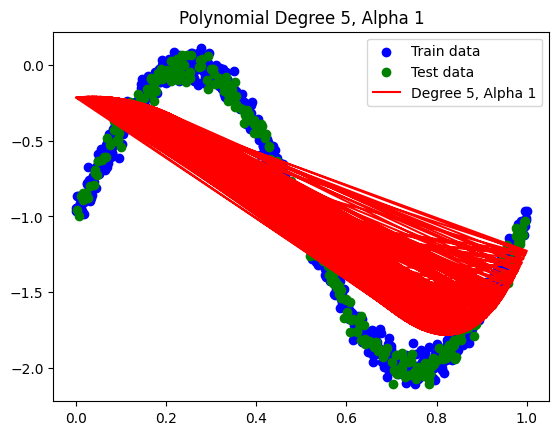

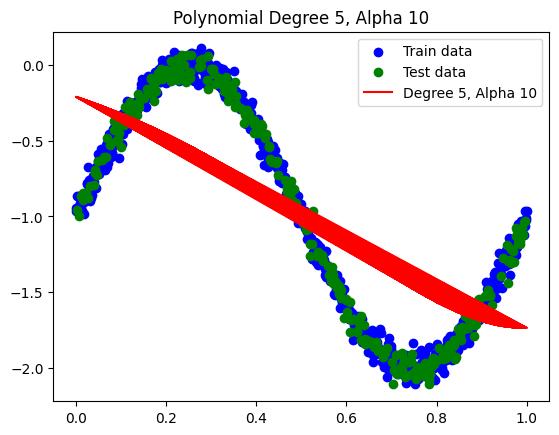

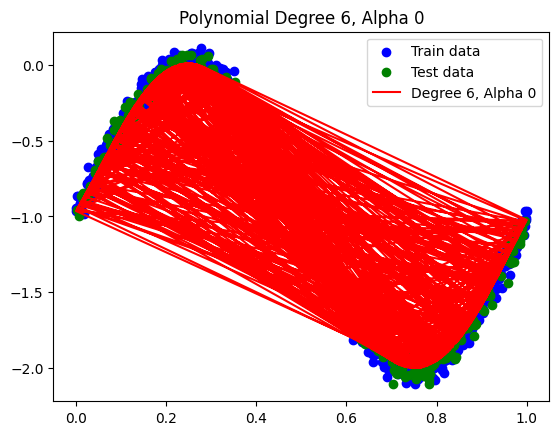

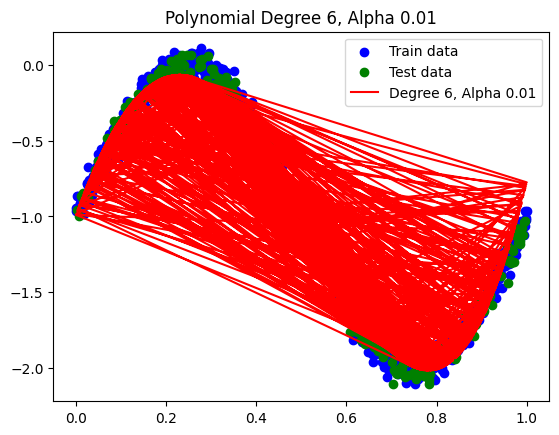

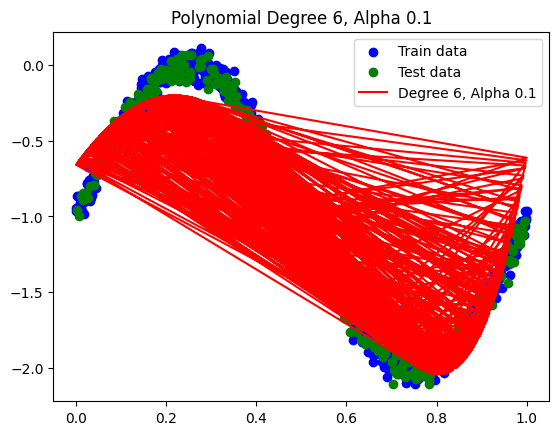

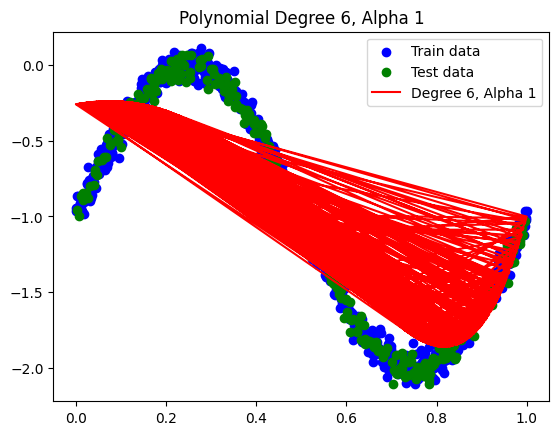

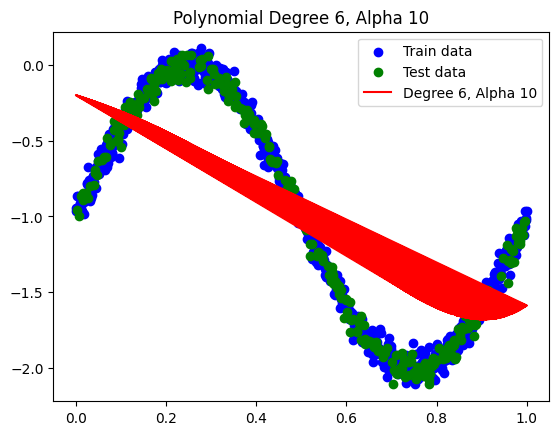

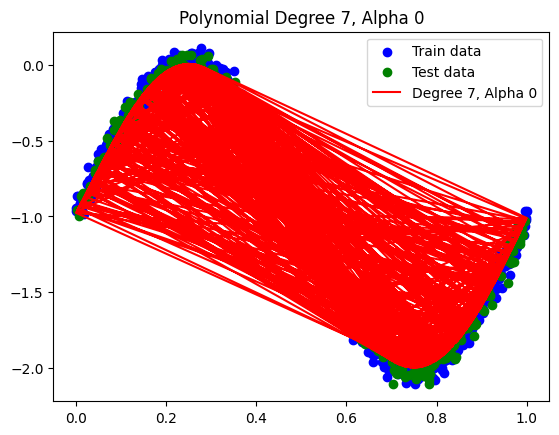

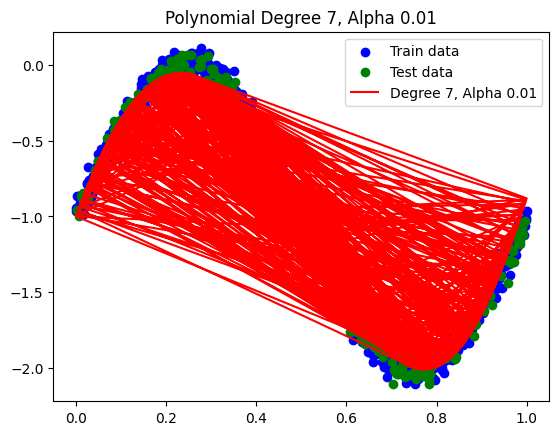

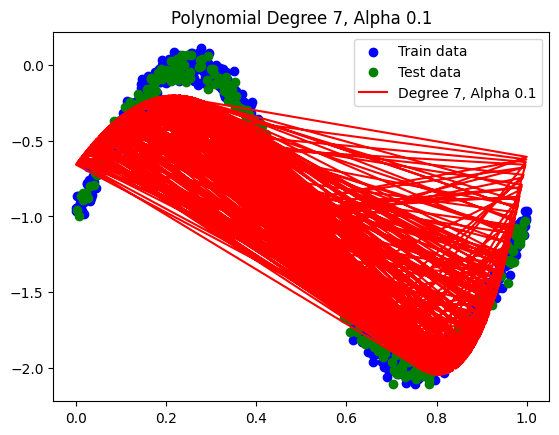

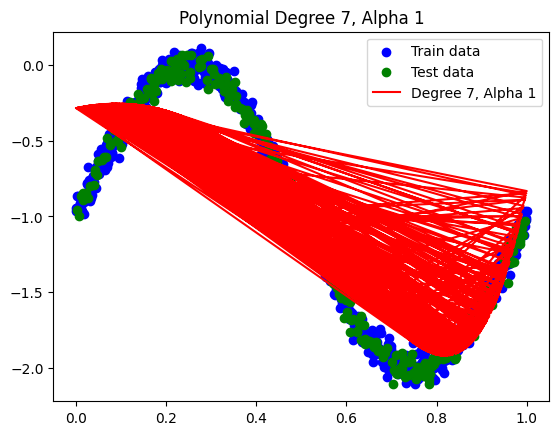

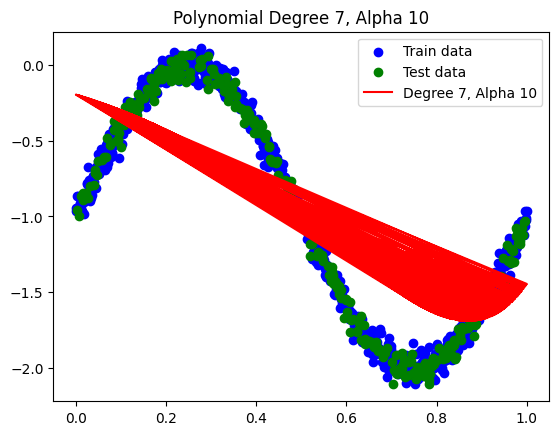

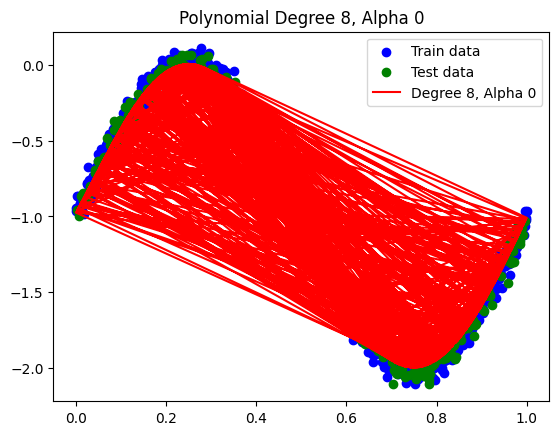

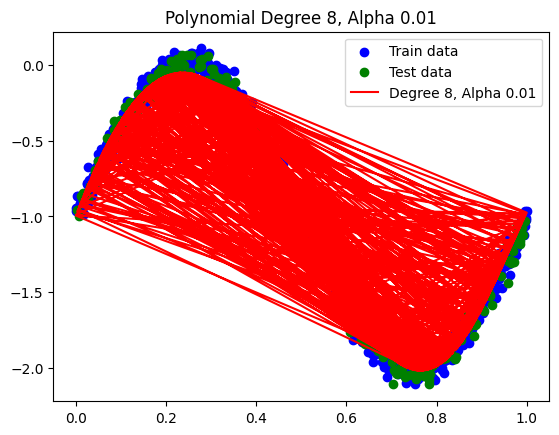

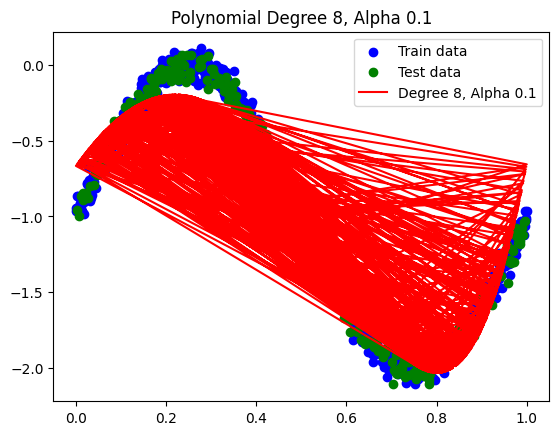

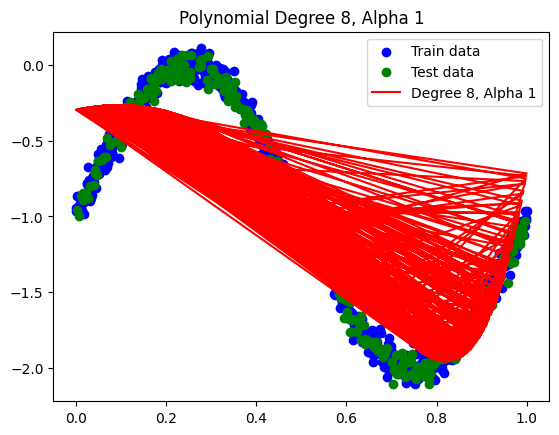

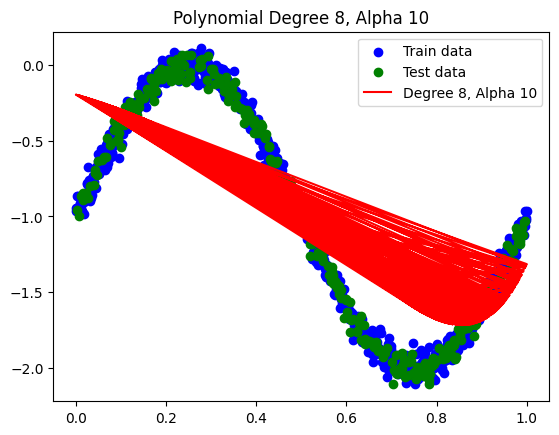

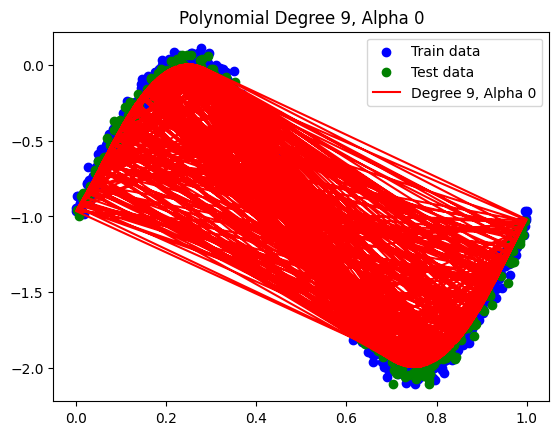

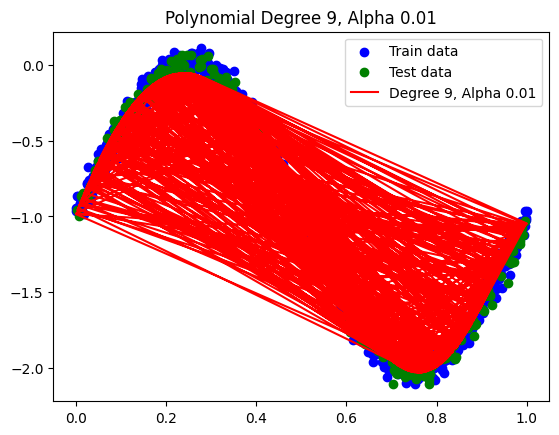

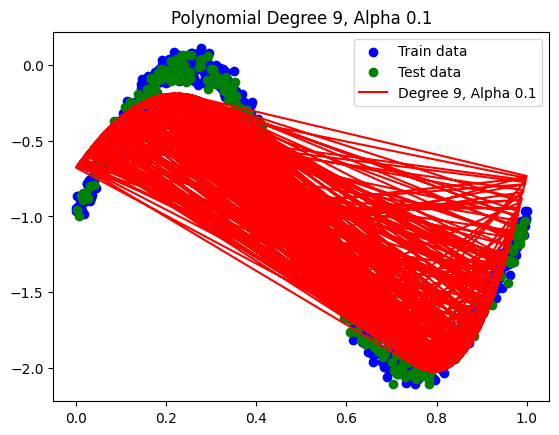

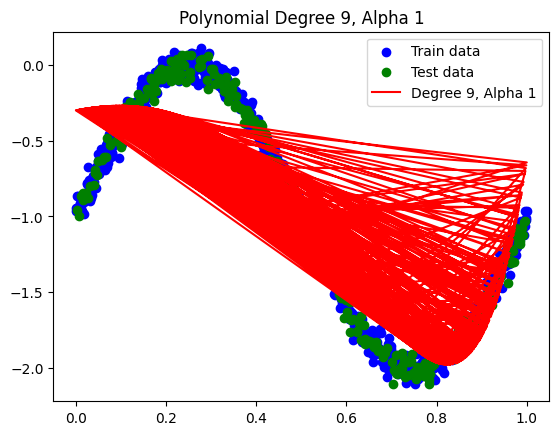

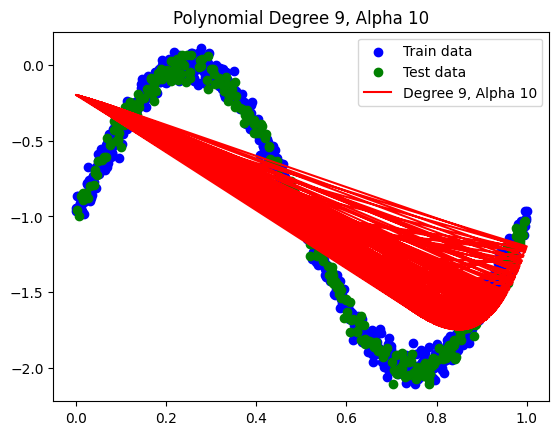

    Degree  Alpha  MSE_Train  MSE_Test  \
0        2   0.00   0.201561  0.190832   
1        2   0.01   0.201561  0.190847   
2        2   0.10   0.201571  0.190987   
3        2   1.00   0.202083  0.192379   
4        2  10.00   0.206375  0.198814   
5        3   0.00   0.007787  0.007780   
6        3   0.01   0.010760  0.009748   
7        3   0.10   0.072647  0.066470   
8        3   1.00   0.170600  0.160058   
9        3  10.00   0.205447  0.197818   
10       4   0.00   0.007787  0.007781   
11       4   0.01   0.011083  0.010538   
12       4   0.10   0.028534  0.024825   
13       4   1.00   0.124780  0.114602   
14       4  10.00   0.191600  0.183319   
15       5   0.00   0.003061  0.002928   
16       5   0.01   0.011444  0.010910   
17       5   0.10   0.025708  0.022956   
18       5   1.00   0.091201  0.081748   
19       5  10.00   0.172717  0.163686   
20       6   0.00   0.003052  0.002969   
21       6   0.01   0.008493  0.007944   
22       6   0.10   0.028739  0.02

In [3]:
# Define polynomial degrees and regularization parameters
degrees = range(2, 10)
alphas = [0, 0.01, 0.1, 1, 10]

# Store results for plotting
results = []

for degree in degrees:
    for alpha in alphas:
        y_train_pred, y_test_pred, weights, mse_train, mse_test = polynomial_regression(X_train, y_train, X_test, y_test, degree, alpha)
        results.append((degree, alpha, mse_train, mse_test, weights))
        
        # Plot the curve for this configuration
        plt.scatter(X_train, y_train, color='blue', label='Train data')
        plt.scatter(X_test, y_test, color='green', label='Test data')
        plt.plot(X_train, y_train_pred, color='red', label=f'Degree {degree}, Alpha {alpha}')
        plt.title(f'Polynomial Degree {degree}, Alpha {alpha}')
        plt.legend()
        plt.show()

# You can store the results for further analysis
results_df = pd.DataFrame(results, columns=['Degree', 'Alpha', 'MSE_Train', 'MSE_Test', 'Weights'])
print(results_df)

## Step 4: MSE Plots and Weight Analysis

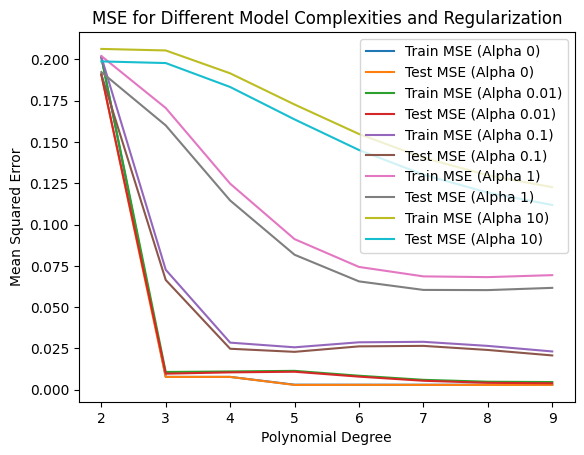

In [4]:
# Plot MSE for different degrees and regularization values
for alpha in alphas:
    train_mse_list = []
    test_mse_list = []
    for degree in degrees:
        _, _, _, mse_train, mse_test = polynomial_regression(X_train, y_train, X_test, y_test, degree, alpha)
        train_mse_list.append(mse_train)
        test_mse_list.append(mse_test)
    
    plt.plot(degrees, train_mse_list, label=f'Train MSE (Alpha {alpha})')
    plt.plot(degrees, test_mse_list, label=f'Test MSE (Alpha {alpha})')

plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('MSE for Different Model Complexities and Regularization')
plt.legend()
plt.show()

## Step 5: Scatter Plot for Target vs Model Output

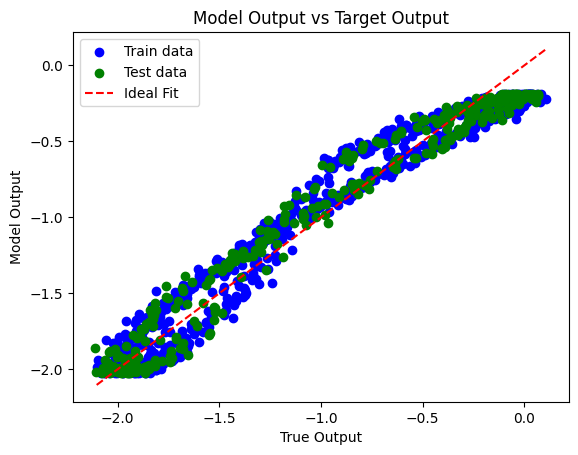

In [5]:
# Best model selection can be done based on cross-validation results
best_degree = 9  # Assume best degree after cross-validation
best_alpha = 0.1  # Assume best regularization after cross-validation

y_train_pred, y_test_pred, _, _, _ = polynomial_regression(X_train, y_train, X_test, y_test, best_degree, best_alpha)

# Scatter plot
plt.scatter(y_train, y_train_pred, color='blue', label='Train data')
plt.scatter(y_test, y_test_pred, color='green', label='Test data')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('True Output')
plt.ylabel('Model Output')
plt.title('Model Output vs Target Output')
plt.legend()
plt.show()